In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/ieee-fraud-detection/sample_submission.csv
/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv
/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv


In [4]:
# IEEE-CIS Fraud Detection
## Model Experiment: Decision Tree

## 1. Install Dependencies

In [11]:
!pip install mlflow dagshub -q

## 2. Clone Repository

In [12]:
!git clone https://github.com/lkhar21/ML-assignment2.git

fatal: destination path 'ML-assignment2' already exists and is not an empty directory.


## 3. Import Libraries

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix

import mlflow
import dagshub

## 4. Initialize DagsHub + MLflow

In [15]:
dagshub.init(
    repo_owner="lkhar21",
    repo_name="ML-assignment2",
    mlflow=True
)

mlflow.set_experiment("DecisionTree_Training")

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=0ac19852-ea44-4ae3-b3e4-6a1a489444d6&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=d233d132ec31a9aba560eee237b44f73810fcac990c58b22a86775128a381a17




Accessing as lkhar21

Initialized MLflow to track repo "lkhar21/ML-assignment2"

Repository lkhar21/ML-assignment2 initialized!

<Experiment: artifact_location='mlflow-artifacts:/bd2c535985884dc982b39dd75bd160b1', creation_time=1777828972824, experiment_id='1', last_update_time=1777828972824, lifecycle_stage='active', name='DecisionTree_Training', tags={'mlflow.experimentKind': 'custom_model_development'}, trace_location=None, workspace='default'>

## 5. Load Dataset

In [16]:
train = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv')

print(train.shape)
train.head()

(590540, 394)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 6. Sampling (Memory Optimization)

In [17]:
train = train.sample(50000, random_state=42)

print(train.shape)

(50000, 394)


## 7. Split Features and Target

In [18]:
y = train['isFraud']
X = train.drop(columns=['isFraud'])

## 8. Cleaning
### Missing Value Handling

In [19]:
num_cols = X.select_dtypes(include=['number']).columns
X[num_cols] = X[num_cols].fillna(-999)

cat_cols = X.select_dtypes(include=['object']).columns
X[cat_cols] = X[cat_cols].fillna("missing")

## 9. Feature Engineering
### Categorical Encoding

In [20]:
for col in cat_cols:
    X[col] = X[col].astype('category').cat.codes

print(X.dtypes.value_counts())

float64    376
int8        14
int64        3
Name: count, dtype: int64


## 10. Visual Data Analysis

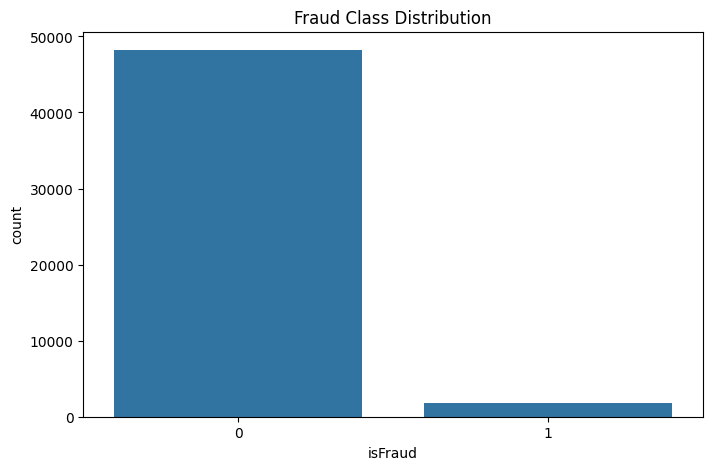

In [21]:
plt.figure(figsize=(8,5))
sns.countplot(x=y)
plt.title("Fraud Class Distribution")
plt.show()

## 10. Feature Selection

In [22]:
# Remove highly correlated features
corr_matrix = X.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]

print("Dropping", len(to_drop), "highly correlated features")

X = X.drop(columns=to_drop)

Dropping 294 highly correlated features


In [23]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)

X = selector.fit_transform(X)

print("Shape after variance filtering:", X.shape)

Shape after variance filtering: (50000, 98)


In [24]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [25]:
with mlflow.start_run(run_name="DecisionTree_FeatureSelection"):

    model = DecisionTreeClassifier(max_depth=6, random_state=42)

    model.fit(X_train, y_train)

    preds = model.predict_proba(X_val)[:, 1]

    auc = roc_auc_score(y_val, preds)

    print("ROC-AUC after FS:", auc)

    mlflow.log_metric("roc_auc", auc)
    mlflow.log_param("feature_selection", "correlation + variance")

ROC-AUC after FS: 0.7739462097078953
🏃 View run DecisionTree_FeatureSelection at: https://dagshub.com/lkhar21/ML-assignment2.mlflow/#/experiments/1/runs/483fc057371840e8a04cf151207085f8
🧪 View experiment at: https://dagshub.com/lkhar21/ML-assignment2.mlflow/#/experiments/1


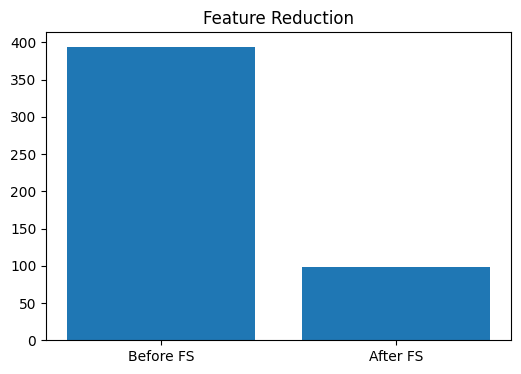

In [26]:
plt.figure(figsize=(6,4))
plt.bar(["Before FS", "After FS"], [394, X.shape[1]])
plt.title("Feature Reduction")
plt.show()

## 11. Train / Validation Split

In [27]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_val.shape)

(40000, 98)
(10000, 98)


## 12. Decision Tree Training

In [50]:
with mlflow.start_run(run_name="DecisionTree_V1"):

    model = DecisionTreeClassifier(
        max_depth=6,
        random_state=42
    )

    model.fit(X_train, y_train)

    preds = model.predict_proba(X_val)[:, 1]

    auc = roc_auc_score(y_val, preds)

    print("ROC-AUC:", auc)

    mlflow.log_param("max_depth", 6)
    mlflow.log_metric("roc_auc", auc)

ROC-AUC: 0.7739462097078953
🏃 View run DecisionTree_V1 at: https://dagshub.com/lkhar21/ML-assignment2.mlflow/#/experiments/1/runs/d9839bc409764cf59dee1720b10113eb
🧪 View experiment at: https://dagshub.com/lkhar21/ML-assignment2.mlflow/#/experiments/1


In [51]:
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=6, random_state=42)

In [66]:
import numpy as np
from sklearn.metrics import f1_score

y_probs = model.predict_proba(X_val)[:, 1]

best_f1 = 0
best_threshold = 0

for t in np.arange(0.05, 0.95, 0.01):
    y_pred = (y_probs >= t).astype(int)
    f1 = f1_score(y_val, y_pred)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print("Best F1:", best_f1)
print("Best Threshold:", best_threshold)

Best F1: 0.4253521126760563
Best Threshold: 0.09000000000000001


In [53]:
from sklearn.metrics import precision_score

In [54]:
from sklearn.metrics import average_precision_score

In [37]:
final_preds = (y_probs >= best_threshold).astype(int)

from sklearn.metrics import classification_report

print(classification_report(y_val, final_preds))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      9627
           1       0.45      0.40      0.43       373

    accuracy                           0.96     10000
   macro avg       0.71      0.69      0.70     10000
weighted avg       0.96      0.96      0.96     10000



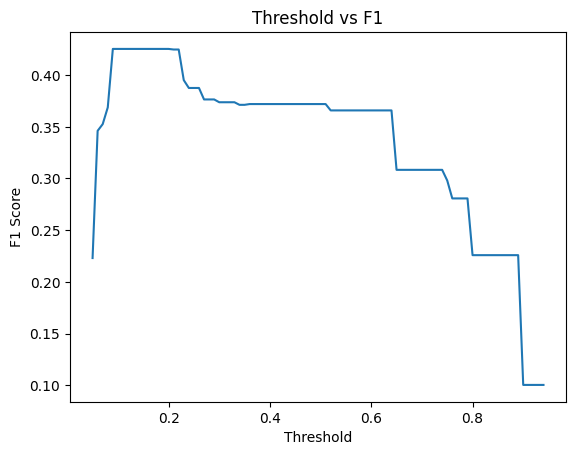

In [38]:
import matplotlib.pyplot as plt

thresholds = np.arange(0.05, 0.95, 0.01)
f1_scores = []

for t in thresholds:
    preds = (y_probs >= t).astype(int)
    f1_scores.append(f1_score(y_val, preds))

plt.plot(thresholds, f1_scores)
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("Threshold vs F1")
plt.show()

In [64]:
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score
)

y_pred = (y_probs >= best_threshold).astype(int)

f1 = f1_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
roc_auc = roc_auc_score(y_val, y_probs)
pr_auc = average_precision_score(y_val, y_probs)

print("📊 FINAL METRICS")
print("-------------------")
print("F1 Score:", f1)
print("Precision:", precision)
print("Recall:", recall)
print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

📊 FINAL METRICS
-------------------
F1 Score: 0.4253521126760563
Precision: 0.44807121661721067
Recall: 0.40482573726541554
ROC-AUC: 0.7739462097078953
PR-AUC: 0.3346293943823598


In [56]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])
print("ROC-AUC:", auc)

ROC-AUC: 0.7739462097078953


In [57]:
from sklearn.metrics import precision_score, recall_score

y_pred = model.predict(X_val)

precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)

print("Precision:", precision)
print("Recall:", recall)

Precision: 0.7322834645669292
Recall: 0.24932975871313673


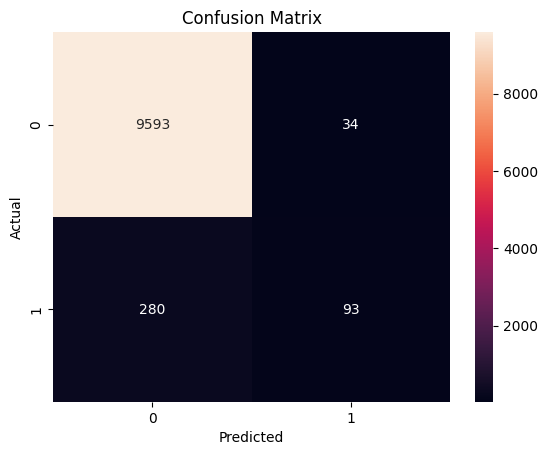

In [58]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [59]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(y_val, model.predict_proba(X_val)[:, 1])
print("PR-AUC:", pr_auc)

PR-AUC: 0.3346293943823598


## 13. Confusion Matrix

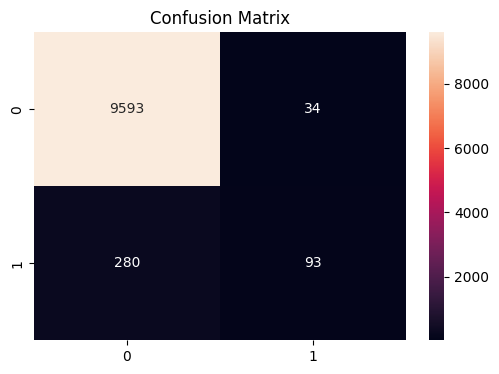

In [29]:
pred_labels = model.predict(X_val)

cm = confusion_matrix(y_val, pred_labels)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

## 14. Feature Importance

In [ ]:
feature_names = X_train_selected.columns

In [ ]:
importances = model.feature_importances_
indices = np.argsort(importances)[-20:]

plt.figure(figsize=(10,8))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), X.columns[indices])
plt.title("Top 20 Important Features")
plt.show()

## 15. Experiment Analysis

In [32]:
print(f"""
Decision Tree Results

ROC-AUC: {auc}

Observations:
- Baseline Decision Tree experiment completed
- MLflow logging successful
- Ready for feature selection experiments
""")


Decision Tree Results

ROC-AUC: 0.7739462097078953

Observations:
- Baseline Decision Tree experiment completed
- MLflow logging successful
- Ready for feature selection experiments



In [33]:
from sklearn.metrics import f1_score

In [ ]:
f1 = f1_score(y_val, model.predict(X_val))

print("ROC-AUC:", auc)
print("F1 Score:", f1)